In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import plot_tree
from sklearn.utils import resample



In [3]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/cleaned.csv")
df

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,...,746,747,748,749,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans
0,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,1,...,3.611793,3.626802,3.618046,3.629302,14.810847,2.800167,1.682722,-0.495984,-0.639443,0
1,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,0,...,13.015418,13.015418,12.986280,13.025130,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0
2,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,0,...,13.015418,12.986280,13.025130,13.034844,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1
3,WLFC,JACOBS SY,2009-01-30,808.0,8.5400,I,False,False,True,0,...,12.986280,13.025130,13.034844,13.073694,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0
4,HXL,HENNEMUTH ROBERT,2009-01-30,400.0,8.0400,D,False,True,False,1,...,18.959692,18.895298,18.922897,19.033287,9.024040,2.269244,1.074058,-0.547370,-0.639443,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,4.873516,2.724795,-0.828549,0.159188,-0.713086,1
97150,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,11.808925,2.727904,1.346064,0.159188,-0.713086,0
97151,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,2.210827,4.251506,-1.188667,2.150396,-0.713086,1
97152,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,9.045543,4.260137,-0.732465,2.150396,-0.639443,1


# Baseline Model

In [4]:
df["target"] = (
    df['5'] >
    df['0']
    ).astype('int8')
df["target"].sum()

np.int64(55795)

In [5]:
num_cols = df.select_dtypes(include=["number", "bool"]).columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = df[num_cols]
df_numeric = df_numeric.drop(columns=["transaction_month", "amounts.shares", "amounts.pricePerShare","filing_count_reportingOwner.name", "trades_14d", "holding_change_percent"])

                Modell  Accuracy   ROC AUC  Precision    Recall
0        Random Forest  0.601260  0.642444   0.594410  0.961424
1  Logistic Regression  0.573812  0.543284   0.576431  0.971366
2              XGBoost  0.661240  0.734916   0.723354  0.663733


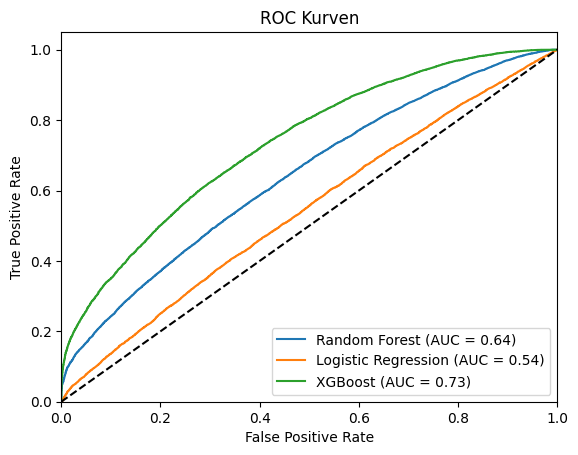

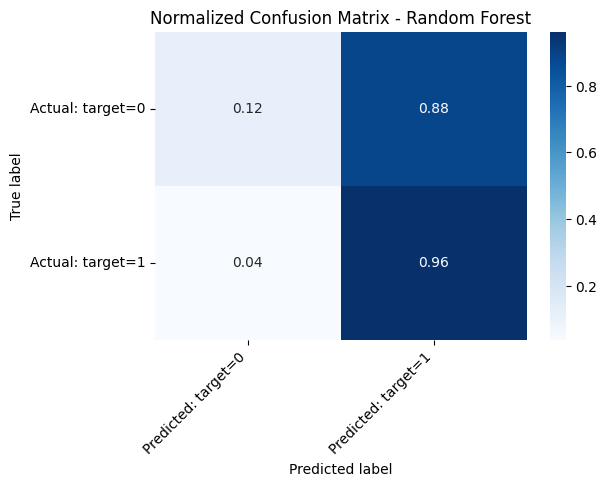

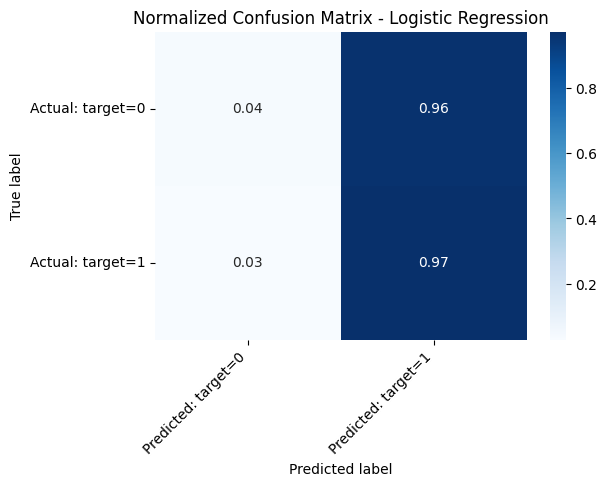

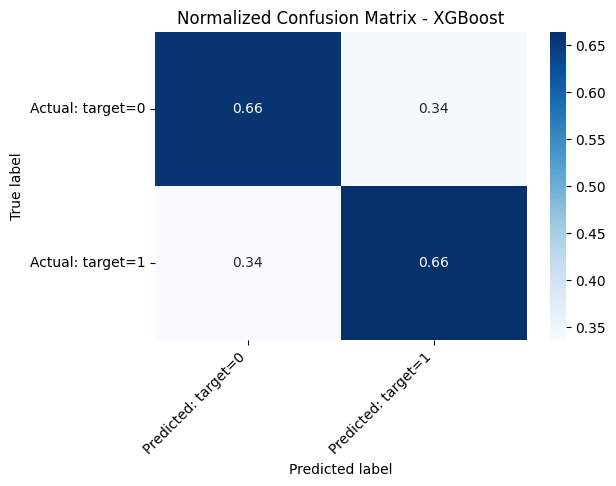

Feature importance for each model:
                                               Logistic Regression  \
high_frequency_trader                                     0.123854   
scaled_trades_14d                                         0.112294   
high_price                                                0.110415   
reportingOwner.relationship.isOfficer                     0.095037   
direct_ownership                                          0.075583   
boxcox_amounts.pricePerShare                              0.074104   
reportingOwner.relationship.isDirector                    0.059713   
month_cos                                                 0.041131   
month_sin                                                 0.032116   
boxcox_amounts_shares                                     0.026861   
kmeans                                                    0.023103   
scaled_filing_count_reportingOwner.name                   0.021865   
high_change_in_holdings                                

In [6]:
y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=420)
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos = neg / pos
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=1200,
        max_depth=10,
        max_features="sqrt",
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight=None,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=420
    ),
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=420,
        n_jobs=-1,
    ),
}

results = []
for model_name, model in models.items():
    if model_name == "XGBoost":
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    accuracy  = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results.append({
        "Modell": model_name,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

results_df = pd.DataFrame(results)
print(results_df)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven')
plt.legend(loc="lower right")
plt.show()

for model_name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    df_cm = pd.DataFrame(cm, index=['Actual: target=0', 'Actual: target=1'],
                         columns=['Predicted: target=0', 'Predicted: target=1'])
    cm_values = df_cm.values.astype('float')
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)

    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    plt.show()

feature_importances = pd.DataFrame(index=X_train.columns)
if "Logistic Regression" in models:
    feature_importances["Logistic Regression"] = np.abs(models["Logistic Regression"].coef_[0])
if "Random Forest" in models:
    feature_importances["Random Forest"] = models["Random Forest"].feature_importances_
if "XGBoost" in models:
    feature_importances["XGBoost"] = models["XGBoost"].feature_importances_

feature_importances = feature_importances.sort_values(by="Logistic Regression", ascending=False)
print("Feature importance for each model:")
print(feature_importances)

In [14]:
log_reg = models["Logistic Regression"].fit(X_train, y_train)
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
or_ = np.exp(coefs)

or_table = pd.DataFrame({
    "Koeffizient": coefs,
    "Odds Ratio": or_,
})

or_table["percent chance target/not target"] = np.where(
    or_table["Odds Ratio"]>=1,
    (or_table["Odds Ratio"]-1)*100,
    -(1-or_table["Odds Ratio"])*100
).round(1)

or_table = or_table.reindex(or_table["Koeffizient"].abs().sort_values(ascending=False).index)
or_table


,Koeffizient,Odds Ratio,percent chance target/not target
high_price,-0.143735,0.866117,-13.4
high_frequency_trader,-0.128370,0.879528,-12.0
reportingOwner.relationship.isOfficer,0.104980,1.110688,11.1
direct_ownership,-0.104443,0.900827,-9.9
scaled_trades_14d,0.101660,1.107007,10.7
boxcox_amounts.pricePerShare,0.084941,1.088653,8.9
reportingOwner.relationship.isDirector,0.056145,1.057751,5.8
month_cos,-0.048760,0.952410,-4.8
kmeans,-0.033527,0.967029,-3.3
month_sin,-0.025602,0.974723,-2.5


In [ ]:
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

rf = RandomForestClassifier(n_estimators=1200,
                            max_depth=10,
                            max_features="sqrt",
                            min_samples_split=20,
                            min_samples_leaf=10,
                            class_weight=None,
                            bootstrap=True,
                            oob_score=True,
                            n_jobs=-1,
                            random_state=42)

results = []

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(10,10),dpi=300,)
fn = list(X_train.columns)
cn = [str(cls) for cls in np.unique(y_train)]

estimator = rf.estimators_[0]

plot_tree(estimator,
feature_names=fn,
class_names=cn,
filled=True,
fontsize=3,
ax=ax)

fig.savefig("baum_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Fine Tune

In [54]:
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]
results_threshold = []

y_pred_prob = models["Random Forest"].predict_proba(X_test)[:, 1]

for thresh in thresholds:
    y_pred_custom = (y_pred_prob >= thresh).astype(int)
    results_threshold.append({
        "Threshold": thresh,
        "Accuracy": accuracy_score(y_test, y_pred_custom),
        "Precision": precision_score(y_test, y_pred_custom, zero_division=0),
        "Recall": recall_score(y_test, y_pred_custom, zero_division=0),
        "F1-Score": 2 * (precision_score(y_test, y_pred_custom, zero_division=0) * recall_score(y_test, y_pred_custom, zero_division=0)) / (precision_score(y_test, y_pred_custom, zero_division=0) + recall_score(y_test, y_pred_custom, zero_division=0) + 1e-10),
        "Predicted 1 %": (y_pred_custom == 1).sum() / len(y_pred_custom) * 100
    })

threshold_df = pd.DataFrame(results_threshold)
print(threshold_df)

   Threshold  Accuracy  Precision    Recall  F1-Score  Predicted 1 %
0       0.50  0.600730   0.594483  0.957892  0.733651      92.498674
1       0.55  0.608746   0.636005  0.744580  0.686023      67.206263
2       0.60  0.548579   0.714208  0.356153  0.475293      28.626680
3       0.65  0.473005   0.918006  0.090030  0.163978       5.629893
4       0.70  0.453916   0.971609  0.050204  0.095474       2.966221
5       0.75  0.445245   0.982839  0.034230  0.066156       1.999314


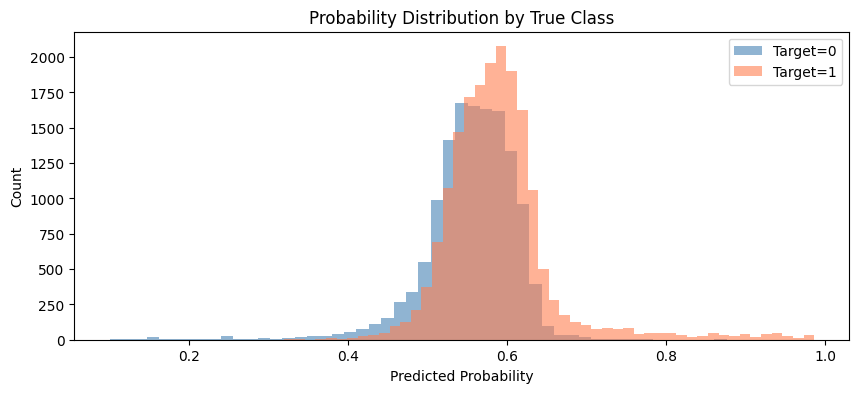

Top 5 Features:
scaled_trades_14d                          0.198894
boxcox_amounts.pricePerShare               0.171322
scaled_filing_count_reportingOwner.name    0.123804
boxcox_amounts_shares                      0.120681
powertransform_holding_change_percent      0.092367
Name: Random Forest, dtype: float64

scaled_trades_14d:
          count      mean       std       min     25%       50%       75%  \
target                                                                      
0       41359.0 -0.046548  0.913069 -0.713086 -0.5658 -0.344871  0.096986   
1       55795.0  0.034504  1.058543 -0.713086 -0.5658 -0.344871  0.170629   

             max  
target            
0       6.062064  
1       6.135706  

boxcox_amounts.pricePerShare:
          count      mean       std       min       25%       50%       75%  \
target                                                                        
0       41359.0  2.827883  1.078913  0.712822  1.981428  2.940770  3.613801   
1       55795.0

In [55]:
plt.figure(figsize=(10, 4))
plt.hist(y_pred_prob[y_test==0], bins=50, alpha=0.6, label='Target=0', color='steelblue')
plt.hist(y_pred_prob[y_test==1], bins=50, alpha=0.6, label='Target=1', color='coral')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution by True Class')
plt.legend()
plt.show()

top_features = feature_importances["Random Forest"].nlargest(5)
print("Top 5 Features:")
print(top_features)

for feat in top_features.index:
    print(f"\n{feat}:")
    print(df_numeric.groupby('target')[feat].describe())

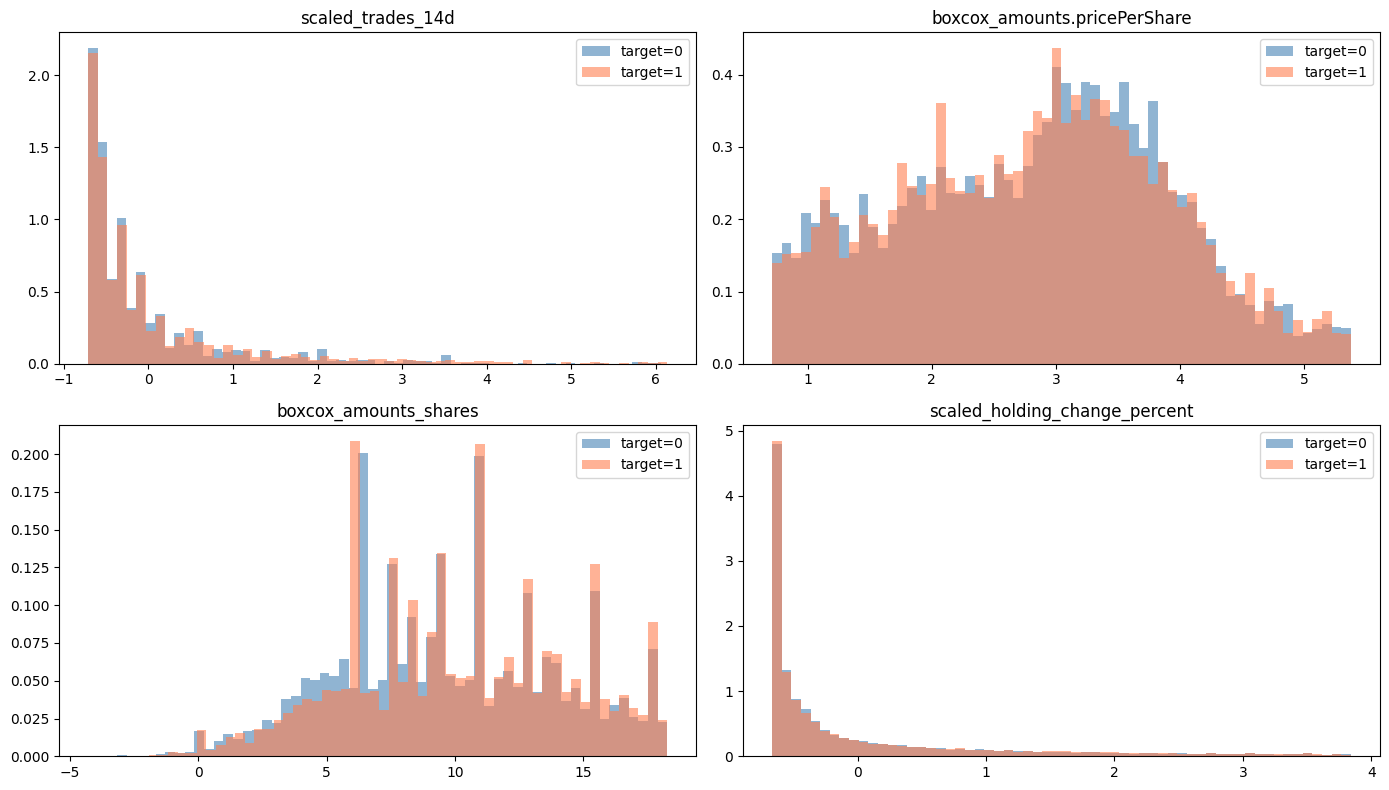

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features_to_check = [
    'scaled_trades_14d', 
    'boxcox_amounts.pricePerShare',
    'boxcox_amounts_shares',
    'scaled_holding_change_percent'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), features_to_check):
    vals_0 = df_numeric[df_numeric['target'] == 0][feat].dropna()
    vals_1 = df_numeric[df_numeric['target'] == 1][feat].dropna()
    ax.hist(vals_0, bins=60, alpha=0.6, label='target=0', density=True, color='steelblue')
    ax.hist(vals_1, bins=60, alpha=0.6, label='target=1', density=True, color='coral')
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

In [7]:
df_numeric['trade_volume_ratio'] = (
    df_numeric['boxcox_amounts_shares'] / 
    (df_numeric['scaled_trades_14d'] + 1e-6)
)

df_numeric['is_large_trade'] = (
    df_numeric['boxcox_amounts_shares'] > 
    df_numeric['boxcox_amounts_shares'].quantile(0.9)
).astype(int)

df_numeric['is_high_activity'] = (
    df_numeric['scaled_trades_14d'] > 
    df_numeric['scaled_trades_14d'].quantile(0.85)
).astype(int)

df_numeric['activity_x_size'] = (
    df_numeric['scaled_trades_14d'] * 
    df_numeric['boxcox_amounts_shares']
)

df_numeric['abs_holding_change'] = df_numeric['powertransform_holding_change_percent'].abs()

In [15]:
for col in ['5', '20', '60']:
    if col in df.columns:
        df[f"target_{col}d"] = (df[col] > df['0']).astype('int8')
        auc = roc_auc_score(
            df[f"target_{col}d"],
            rf.predict_proba(X)[:, 1]
        )
        print(f"Horizont {col} Days with AUC: {auc:.3f}")

Horizont 5 Days with AUC: 0.701
Horizont 20 Days with AUC: 0.617
Horizont 60 Days with AUC: 0.563


In [73]:
df_numeric.drop(columns=["high_price", "high_frequency_trader", "high_change_in_holdings", "powertransform_holding_change_percent", "reportingOwner.relationship.isOfficer", 
                         "reportingOwner.relationship.isDirector", "reportingOwner.relationship.isTenPercentOwner", "direct_ownership"])

,month_sin,month_cos,boxcox_amounts_shares,boxcox_amounts.pricePerShare,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans,target,trade_volume_ratio,is_large_trade,is_high_activity,activity_x_size,abs_holding_change
0,5.000000e-01,0.866025,14.810847,2.800167,-0.495984,-0.639443,0,0,-23.162146,0,0,-9.470692,1.682722
1,5.000000e-01,0.866025,12.763522,2.349076,-0.487419,-0.639443,0,1,-19.960408,0,0,-8.161544,0.534718
2,5.000000e-01,0.866025,9.971760,2.357344,-0.487419,-0.565800,1,1,-17.624209,0,0,-5.642022,0.949839
3,5.000000e-01,0.866025,10.613207,2.340755,-0.487419,-0.492157,0,0,-21.564718,0,0,-5.223365,0.879243
4,5.000000e-01,0.866025,9.024040,2.269244,-0.547370,-0.639443,1,1,-14.112369,0,0,-5.770359,1.074058
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,-2.449294e-16,1.000000,4.873516,2.724795,0.159188,-0.713086,1,1,-6.834413,0,0,-3.475235,0.828549
97150,-2.449294e-16,1.000000,11.808925,2.727904,0.159188,-0.713086,0,1,-16.560336,0,0,-8.420777,1.346064
97151,-2.449294e-16,1.000000,2.210827,4.251506,2.150396,-0.713086,1,0,-3.100370,0,0,-1.576509,1.188667
97152,-2.449294e-16,1.000000,9.045543,4.260137,2.150396,-0.639443,1,0,-14.145997,0,0,-5.784109,0.732465


In [81]:
df_numeric["target"] = ((df['5'] / df['0'] - 1) > 0.02).astype('int8')

Training after balancing:
target
0    22687
1    22687
Name: count, dtype: int64
                Modell  Threshold  Accuracy   ROC AUC  Precision    Recall
0        Random Forest       0.55  0.673279  0.678059   0.534716  0.403383
1  Logistic Regression       0.55  0.612832  0.586195   0.424759  0.347024
2              XGBoost       0.55  0.611865  0.751258   0.464555  0.824046


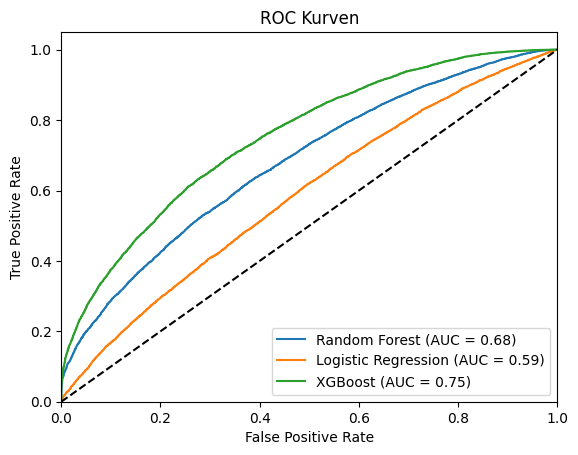

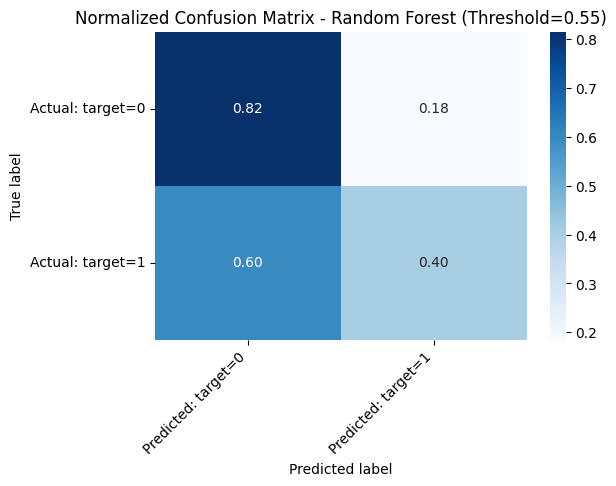

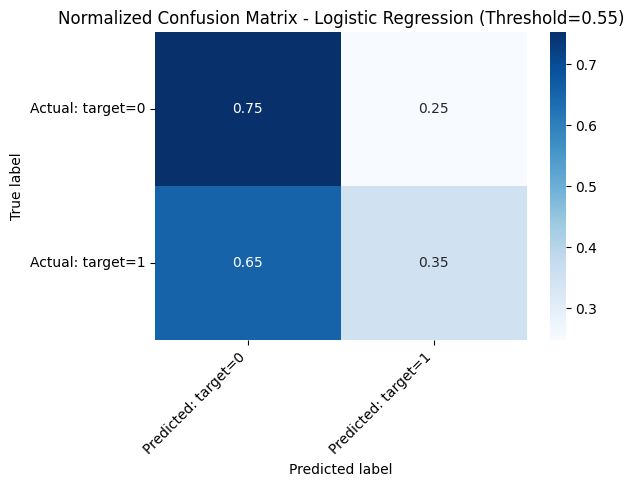

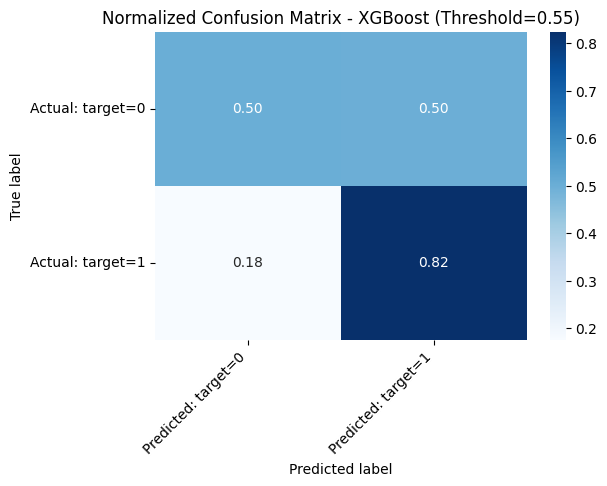

Feature importance for each model:
                                               Logistic Regression  \
high_frequency_trader                                     0.329592   
scaled_trades_14d                                         0.237205   
reportingOwner.relationship.isTenPercentOwner             0.218058   
high_price                                                0.217628   
reportingOwner.relationship.isOfficer                     0.146558   
reportingOwner.relationship.isDirector                    0.118183   
kmeans                                                    0.044467   
is_large_trade                                            0.043888   
boxcox_amounts_shares                                     0.040105   
month_cos                                                 0.039230   
direct_ownership                                          0.035855   
boxcox_amounts.pricePerShare                              0.031166   
is_high_activity                                       

In [ ]:
THRESHOLD = 0.55

y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=420
)

df_train = X_train.copy()
df_train['target'] = y_train
df_majority = df_train[df_train['target'] == df_train['target'].value_counts().idxmax()]
df_minority = df_train[df_train['target'] == df_train['target'].value_counts().idxmin()]
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=420
)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(
    frac=1, random_state=420
)
X_train_bal = df_balanced.drop(columns=['target'])
y_train_bal = df_balanced['target']

print("Training after balancing:")
print(y_train_bal.value_counts())

scale_pos = len(df_majority) / len(df_minority)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=1200,
        max_depth=10,
        max_features="sqrt",
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=420
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=10000,
        class_weight="balanced",
    ),
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos, 
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=420,
        n_jobs=-1,
    ),
}

results = []
for model_name, model in models.items():
    if model_name == "XGBoost":
        model.fit(
            X_train_bal, y_train_bal,
            eval_set=[(X_test, y_test)],
            verbose=False
        )
    else:
        model.fit(X_train_bal, y_train_bal)

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob >= THRESHOLD).astype(int)

    accuracy  = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results.append({
        "Modell": model_name,
        "Threshold": THRESHOLD,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

results_df = pd.DataFrame(results)
print(results_df)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven')
plt.legend(loc="lower right")
plt.show()

for model_name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob >= THRESHOLD).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    df_cm = pd.DataFrame(cm, index=['Actual: target=0', 'Actual: target=1'],
                         columns=['Predicted: target=0', 'Predicted: target=1'])
    cm_values = df_cm.values.astype('float')
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)

    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name} (Threshold={THRESHOLD})')
    plt.show()

feature_importances = pd.DataFrame(index=X_train_bal.columns)

if "Logistic Regression" in models:
    feature_importances["Logistic Regression"] = np.abs(
        models["Logistic Regression"].coef_[0]
    )
if "Random Forest" in models:
    feature_importances["Random Forest"] = models["Random Forest"].feature_importances_

if "XGBoost" in models:
    feature_importances["XGBoost"] = models["XGBoost"].feature_importances_

feature_importances = feature_importances.sort_values(
    by="Logistic Regression", ascending=False
)
print("Feature importance for each model:")
print(feature_importances)